In [36]:
import seaborn as sns 
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [37]:
iris = load_iris()

In [45]:
X = iris.data
y = iris.target


In [46]:
X.shape

(150, 4)

<Axes: >

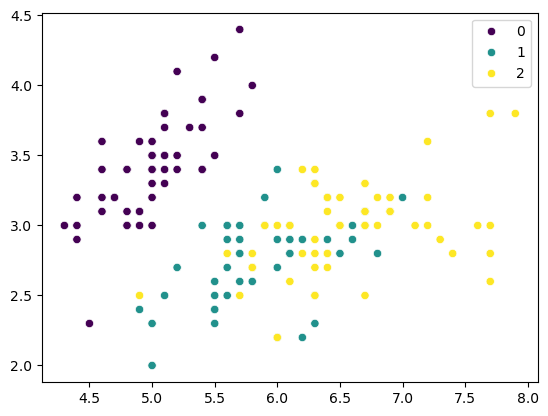

In [55]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis')

In [ ]:
# scaling of the data 

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [70]:
# dimensionallity reduction using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

In [71]:
wcss = []
for k in range(1,11):
    kmeans =KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

C:\Users\amutk\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amutk\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amutk\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amutk\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

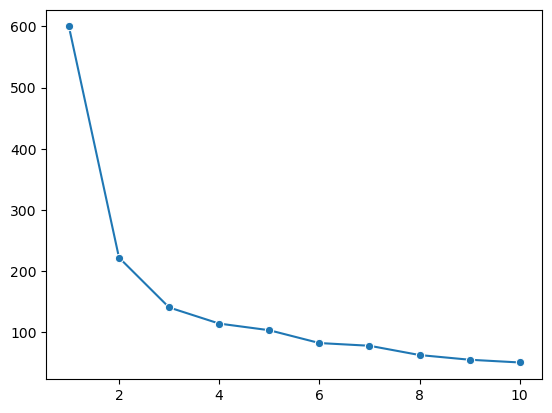

In [62]:
sns.lineplot(x=range(1,11),y=wcss,marker="o")

In [72]:
from kneed import KneeLocator
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [73]:
print("Optimal k value",knee.elbow)

Optimal k value 3


C:\Users\amutk\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

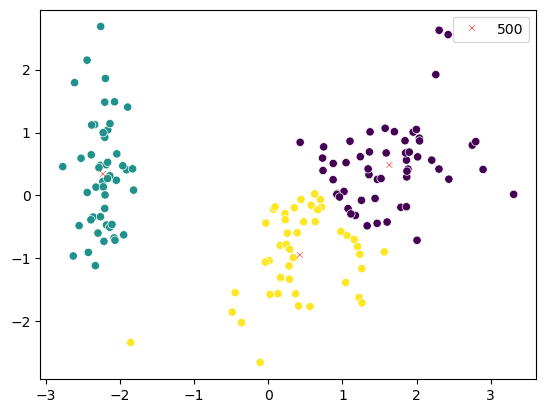

In [82]:
# KMeans 
kmeans = KMeans(n_clusters = 3,random_state = 10)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1],marker="x",c="red",size=500)
